In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from scipy.spatial import distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from scipy.spatial.distance import cosine
from sklearn.manifold import MDS, TSNE 

In [2]:
n_community = 2
n_members = 3

tokens = ['@']

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [3]:
class brain(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers=1, num_layers_sleep=1, output_size=8):
        super(brain, self).__init__()

        self.rnn = nn.RNN(input_size+sleep_output_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_rnn = nn.RNN(1, hidden_sleep_size, num_layers_sleep, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, sleep_output_size)
        self.wake_fc = nn.Linear(hidden_wake_size, output_size)
        self.sleep_output_size = sleep_output_size

    def forward(self, x, x_=None, hw=None, hs=None, sleep=False):
        # print(x.shape, 'x')
        if sleep:
            if hs == None:
                out, hs = self.sleep_rnn(x_)
            else:
                out, hs = self.sleep_rnn(x_, hs)
            # print(out.shape)
            sleep_out = self.sleep_fc(out)
        else:
            sleep_out = torch.zeros((1,x.size(1),self.sleep_output_size))
            
        # print(x.size())
        x = torch.cat((x,sleep_out), dim=2)
        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        # out_ = self.fc(out) 
        out = self.wake_fc(out[:,-1,:])

        if sleep:
            return out, hw, hs
        else:
            return out, hw


In [4]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [5]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data)+1, len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-64] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [8]:
gen_seq(100)

'CECCECDCDAACBBCGDCADCBECCEEGCGEADEBAADBBEGCGEGACGBAFEBGECCECGGACGBCDCFCEGECAEFBFDCEEGACEBCDGEDAECBCD'

In [7]:
def gen_seq(total_samples):
    seq = []

    for _ in range(total_samples):
        token = chr(ord('A') + np.random.choice(7))

        if token == 'B':
            seq.append('C') 
        else:
            seq.append(token)
        
    for ii, ch in enumerate(seq):
        if ch == 'A' and ii+3<total_samples:
            seq[ii+3] = 'B'
    
    return ''.join(seq)


In [9]:
def add_silence(data, silence_length=5):
    silent_data = ''

    for ch in data:
        silent_data = silent_data + ch +  '@'*silence_length

    return silent_data

In [10]:
### initial training ###
total_samples = 60000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 40
hidden_sleep_size = 10
sleep_output_size = 5
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = len(tokens)*working_memory
lr = 4e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)#gen_seq(total_samples) #
data = add_silence(data)

data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = brain(input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = network1(X)
    else:
        predicted_y, hidden = network1(X, hw=mem)
    
    # print(predicted_y.shape, y.shape)
    loss = criterion(predicted_y, y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')


Iter : 1001, loss: 0.1798, accuracy: 0.8280
Iter : 2001, loss: 0.1651, accuracy: 0.8330
Iter : 3001, loss: 3.7318, accuracy: 0.8330
Iter : 4001, loss: 0.2215, accuracy: 0.8340
Iter : 5001, loss: 0.1873, accuracy: 0.8330
Iter : 6001, loss: 2.5870, accuracy: 0.8330
Iter : 7001, loss: 0.2260, accuracy: 0.8340
Iter : 8001, loss: 0.0481, accuracy: 0.8330
Iter : 9001, loss: 4.0886, accuracy: 0.8330
Iter : 10001, loss: 0.0444, accuracy: 0.8340
Iter : 11001, loss: 0.0487, accuracy: 0.8360
Iter : 12001, loss: 2.9123, accuracy: 0.8550
Iter : 13001, loss: 0.0162, accuracy: 0.8470
Iter : 14001, loss: 0.0002, accuracy: 0.8340
Iter : 15001, loss: 2.1410, accuracy: 0.8430
Iter : 16001, loss: 0.0045, accuracy: 0.8400
Iter : 17001, loss: 0.0000, accuracy: 0.8440
Iter : 18001, loss: 2.0602, accuracy: 0.8360
Iter : 19001, loss: 0.0402, accuracy: 0.8410
Iter : 20001, loss: 0.0000, accuracy: 0.8470
Iter : 21001, loss: 2.2157, accuracy: 0.8570
Iter : 22001, loss: 0.0009, accuracy: 0.8530
Iter : 23001, loss:

KeyboardInterrupt: 

In [29]:
def mse_contrastive_loss(pivot, pos, neg, repel_margin=50.0):
    pull_loss = nn.functional.mse_loss(pivot, pos)
    d_neg = ((pivot.unsqueeze(1) - neg) ** 2).sum(dim=-1) 
    repel_loss = torch.relu(repel_margin - d_neg).mean()

    return pull_loss + repel_loss


In [30]:
class place_cells(nn.Module):
    def __init__(self, input_size, output_size):
        super(place_cells, self).__init__()
        
        self.linear1 = nn.utils.weight_norm(nn.Linear(input_size, output_size))

    def forward(self, x):
        out = self.linear1(x)

        return out

In [114]:
total_samples = 200000
idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
counts = []
seq = ''
seq_ = ''

place_cell = place_cells(hidden_wake_size, 10)
optimizer = torch.optim.SGD(place_cell.parameters(), lr=1e-3, momentum=0.95)
criterion = mse_contrastive_loss

for jj in range(total_samples):
    with torch.no_grad():
        if jj == 0:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1))
        else:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hidden_state)

        X_hat_prob = torch.nn.functional.softmax(X_hat_, dim=1)
        dist_categ = torch.distributions.Categorical(probs=X_hat_prob.reshape(-1))
        idx = dist_categ.sample()

        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)
        seq = seq + tokens[idx]


        #### Mine positive and negative examples ####
        X_pos = torch.zeros(len(tokens),dtype=torch.float32)
        idx = X_hat_prob.argmax()
        X_pos[idx] = 1.0
        X_pos = X_pos.reshape(1,1,-1)
        _, hidden_state_pos = network1(X_pos, hidden_state)

        X_neg = torch.zeros(len(tokens),dtype=torch.float32)
        idx = X_hat_prob.argmin()
        X_neg[idx] = 1.0
        X_neg = X_neg.reshape(1,1,-1)
        _, hidden_state_neg = network1(X_neg, hidden_state)
 
        
    optimizer.zero_grad()

    out1 = place_cell(hidden_state.reshape(-1))
    out2 = place_cell(hidden_state_pos.reshape(-1))
    out_neg = place_cell(hidden_state_neg.reshape(-1))
    
    loss = criterion(out1,out2,out_neg)
    loss.backward(retain_graph=True)
    optimizer.step()

    if jj%10000==0:
        print('Loss',loss.item())
    
        

Loss 47.2176399230957
Loss 9.778283856576309e-05
Loss 0.00030441954731941223
Loss 0.0
Loss 0.0


KeyboardInterrupt: 

In [116]:
total_samples = 10
idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
counts = []
seq = ''

for jj in range(total_samples):
    with torch.no_grad():
        # print(X_hat)
        print(tokens[X_hat.argmax()])
        if jj == 0:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1))
        else:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hidden_state)

        print(hidden_state, 'hidden state', tokens[X_hat.argmax()])
        X_hat_prob = torch.nn.functional.softmax(X_hat_, dim=1)
        print(X_hat_prob)
        dist_categ = torch.distributions.Categorical(probs=X_hat_prob.reshape(-1))
        idx = dist_categ.sample()


        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)
        seq = seq + tokens[idx]


        #### Mine positive and negative examples ####
        X_pos = torch.zeros(len(tokens),dtype=torch.float32)
        idx = X_hat_prob.argmax()
        X_pos[idx] = 1.0
        X_pos = X_pos.reshape(1,1,-1)
        _, hidden_state_pos = network1(X_pos, hidden_state)
        print(tokens[idx], ' max', idx)

        X_neg = torch.zeros(len(tokens),dtype=torch.float32)
        idx = X_hat_prob.argmin()
        X_neg[idx] = 1.0
        X_neg = X_neg.reshape(1,1,-1)
        _, hidden_state_neg = network1(X_neg, hidden_state)
        print(tokens[idx], ' min', idx)

        out1 = place_cell(hidden_state.reshape(-1))
        out2 = place_cell(hidden_state_pos.reshape(-1))
        out_neg = place_cell(hidden_state_neg.reshape(-1))
        
        print(out1, out2, out_neg)
    
        

D
tensor([[[0.0000, 0.8696, 0.0000, 0.3586, 1.0485, 0.0372, 0.0000, 0.0000,
          0.9100, 0.0000, 0.8559, 0.0000, 0.4905, 0.0000, 1.1752, 0.0083,
          2.2142, 0.1714, 0.0000, 0.9188, 0.0000, 0.0000, 0.2293, 0.2791,
          0.1819, 0.0000, 0.7018, 0.8132, 0.0944, 0.0147, 0.7743, 0.0533,
          2.0245, 0.0847, 0.0279, 0.0000, 0.0000, 0.0237, 0.0000, 0.0000]]]) hidden state D
tensor([[1.0000e+00, 1.9134e-09, 2.0479e-09, 1.9086e-09, 6.9144e-10, 1.2097e-09,
         1.8911e-09, 3.0312e-09]])
@  max tensor(0)
D  min tensor(4)
tensor([-1.2816,  2.2557, -1.2506, -1.2614,  2.1922,  2.7646, -1.5828, -1.2818,
         1.9073, -1.2730]) tensor([-1.2816,  2.2557, -1.2506, -1.2614,  2.1834,  2.7646, -1.5828, -1.2790,
         1.8984, -1.2730]) tensor([-1.2816,  2.2557, -1.2506, -1.2614,  2.1922,  2.7646, -1.5828, -1.2818,
         1.9073, -1.2730])
@
tensor([[[0.0000, 0.0296, 0.0082, 0.2388, 0.2028, 0.0015, 0.0000, 0.1180,
          0.1555, 0.0000, 0.2882, 0.0000, 0.1634, 0.0000, 0.246

In [115]:
seq[:1000]

'@F@@F@@E@@C@D@@A@@@G@C@@G@G@C@@@G@G@@@G@D@C@@@F@F@@@F@B@@@@B@@B@@@G@D@@G@@@A@C@B@E@@@@@C@@@G@@@D@D@A@@@G@@@@@@F@E@D@@@B@@F@G@G@G@A@D@A@@G@@@@G@C@E@F@@G@A@C@D@@A@F@@@@C@@@G@D@@G@@G@D@G@A@@@@B@@@G@@@A@@@@A@B@@G@G@@@B@@F@@@@G@@G@F@F@@@@@F@G@@@@D@@C@E@@D@G@@@G@G@@@A@G@@@@@G@@C@F@@B@@@@@@@B@B@@B@@@@F@C@G@G@D@@A@B@A@@@@@C@C@C@@@@B@D@G@C@A@G@@@@G@@A@E@B@@G@@@B@B@@E@E@G@C@G@@@@G@E@@@@A@C@@G@A@F@F@@D@@G@E@E@D@@@@B@@G@@A@B@@F@@@G@C@@F@B@@@@@@E@F@@B@E@E@G@@@@@E@F@@D@F@@F@@E@@@@@C@G@@D@C@F@E@E@@@G@G@G@@@G@@@G@@@@G@C@@C@@C@@@@@@@A@A@@D@D@@E@E@C@A@E@@A@@G@@B@@E@@@@@@@E@G@@@@B@@@@G@@@G@D@@G@E@@D@@D@A@@@F@B@G@@@G@F@D@F@@A@@G@D@A@G@G@@G@G@E@@D@G@A@@F@D@E@G@@@@E@@@@@@D@@@@@@@@@A@B@@@@G@@@F@@@@@@G@@@C@@@@@@G@@F@G@A@@@@E@@A@B@@@G@@@@@@A@D@@@@B@A@@@@G@@@@@E@B@@@@@@E@A@@G@C@@@B@@C@G@@D@@G@@D@@C@@@@@@@@@@F@@F@D@@@@@@G@F@B@E@E@@@B@@@@G@@@@@@@A@@@@B@C@G@B@A@@@D@@A@@E@G@G@@@B@@@D@@@@F@B@@@D@A@B@@@F@@F@@B@A@G@@@D@@A@@G@@@G@G@@G@C@@@@@D@F@C@C@@E@@@@G@E@@@@@@A@C@G@@@C@@@E@G@@@@@@G@@D@D@F@@@C@@B@F@D@D@@@@@B@D@@@@@

In [50]:
data[:1000]

,Dimension 1,Dimension 2,token
0,0.435266,-0.323389,B
1,-0.086755,0.066749,@
2,-0.086755,0.066749,@
3,-0.086755,0.066749,@
4,-0.086755,0.066749,@
...,...,...,...
593,-0.086755,0.066749,@
594,0.427812,-0.328613,G
595,-0.086755,0.066749,@
596,-0.086755,0.066749,@


In [13]:
total_samples = 100

data = gen_seq(total_samples) #get_sequence(total_samples, n_community, n_members, train_percent=1.0)
data = add_silence(data)

data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)
hidden_states = []
token = []
jj =0 

for X_hat, _ in train_loader:
    with torch.no_grad():
        # print(X_hat)
        # print(tokens[X_hat.argmax()])
        if jj == 0:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1))
        else:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hidden_state)

        hidden_states.append(hidden_state[0][0])
        token.append(tokens[X_hat.argmax()])
        jj += 1


        
    
        

In [14]:
D = np.zeros((len(hidden_states), len(hidden_states)), dtype=float)

for ii in range(len(hidden_states)):
    for jj in range(len(hidden_states)):
        D[ii,jj] = cosine(hidden_states[ii], hidden_states[jj]) 

# hidden_states = np.array(hidden_states)
embedding = MDS(n_components=2, dissimilarity='precomputed', random_state=101)#TSNE(n_components=2, perplexity=30, random_state=42)#
X_transformed = embedding.fit_transform(D)

In [15]:
data = pd.DataFrame()

states = np.array(hidden_states)
for ii in range(2):
    data['Dimension '+str(ii+1)] = X_transformed[:,ii]#states[:,ii]#

data['token'] = token

<Axes: xlabel='Dimension 1', ylabel='Dimension 2'>

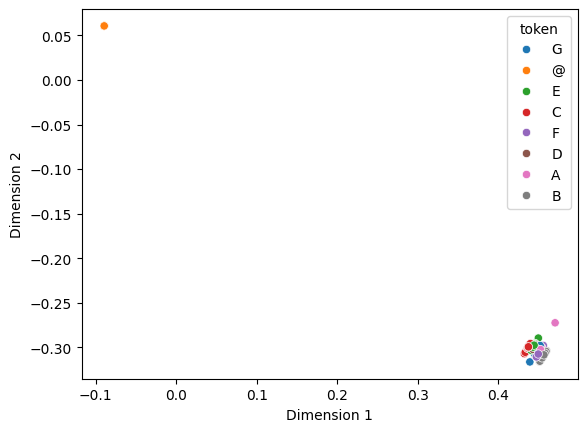

In [16]:
sns.scatterplot(data, x='Dimension 1', y= 'Dimension 2', hue="token")
# plt.savefig('plots/MDS_embedding.pdf', bbox_inches='tight')

In [49]:
X_transformed[:20]

array([[ 0.43526612, -0.32338924],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [ 0.44907632, -0.33940986],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [ 0.41504037, -0.31848288],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [-0.0867552 ,  0.06674854],
       [ 0.4281206 , -0.3282069 ],
       [-0.0867552 ,  0.06674854]])

In [17]:
token[:10]

['G', '@', '@', '@', '@', '@', 'E', '@', '@', '@']

In [51]:
data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)
data = add_silence(data)

In [107]:
data[:100]

,Dimension 1,Dimension 2,token
0,0.016789,0.015021,A
1,-0.002906,0.006974,C
2,-0.021899,0.010666,G
3,0.000918,0.016407,B
4,-0.002906,0.006974,C
...,...,...,...
93,-0.021899,0.010666,G
94,-0.021899,0.010666,G
95,-0.006966,-0.019413,D
96,-0.006966,-0.019413,D


In [106]:
D[:4]

array([[1.73177901e-08, 1.88827925e-02, 3.96783295e-02, 2.64067642e-02,
        1.88827925e-02, 3.14917534e-02, 3.14917534e-02, 1.88827925e-02,
        1.88827925e-02, 1.73177901e-08, 3.14917534e-02, 1.88827925e-02,
        2.64067642e-02, 3.14917534e-02, 1.88827925e-02, 3.14917534e-02,
        3.88804364e-02, 3.14917534e-02, 3.88804364e-02, 1.88827925e-02,
        3.96783295e-02, 1.73177901e-08, 3.88804364e-02, 3.88804364e-02,
        2.64067642e-02, 3.96783295e-02, 3.96783295e-02, 3.14917534e-02,
        3.88804364e-02, 1.88827925e-02, 3.14917534e-02, 3.14917534e-02,
        3.96783295e-02, 3.88804364e-02, 3.88804364e-02, 1.88827925e-02,
        3.96783295e-02, 3.96783295e-02, 1.88827925e-02, 3.14917534e-02,
        1.88827925e-02, 1.88827925e-02, 3.65877970e-02, 3.65877970e-02,
        3.96783295e-02, 3.65877970e-02, 3.96783295e-02, 3.65877970e-02,
        1.73177901e-08, 1.88827925e-02, 3.96783295e-02, 2.64067642e-02,
        3.14917534e-02, 3.96783295e-02, 1.88827925e-02, 1.888279

In [98]:
X_hat 

tensor([[[0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 1., 0.]]])